# Task 1: ITSM Incident Clustering
**NewRocket Case Study | Hemanth Chebiyam**

---

## 1. Overview

This notebook demonstrates a simple, explainable clustering pipeline for ServiceNow incident data. 

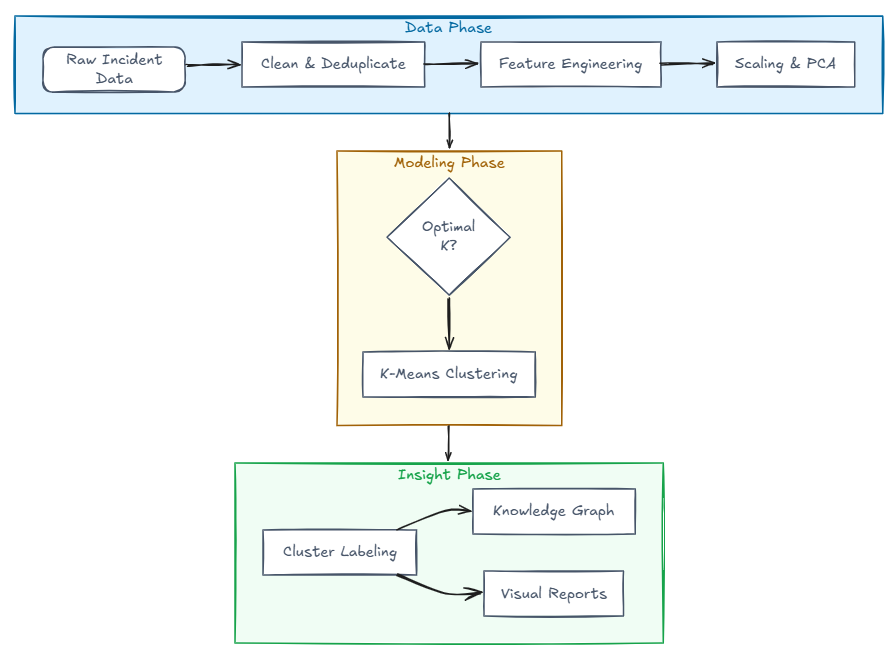

### Dataset
**UCI Incident Management Process Enriched Event Log**
* This is a real export from a ServiceNow production instance.
* 141,712 events → Deduplicated to unique incidents (~24k).


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import networkx as nx
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Paths
DATA_PATH = 'data/incident_event_log.csv'
OUTPUT_DIR = 'outputs'


## 2. Data Loading & Exploratory Data Audit

I loaded the raw dataset, ensuring that '?' characters (common in this UCI dataset) are treated as missing values (`NaN`). This allows for accurate null analysis.

In [22]:
# 1. Load Data (Treating '?' as NaN)
df_raw = pd.read_csv(DATA_PATH, na_values='?', low_memory=False)
print(f"Raw data shape: {df_raw.shape}")

Raw data shape: (141712, 36)


In [23]:
# 2. Schema and Variable Information
print("--- Dataset Schema ---")
df_raw.info()

--- Dataset Schema ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141712 entries, 0 to 141711
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   number                   141712 non-null  object
 1   incident_state           141712 non-null  object
 2   active                   141712 non-null  bool  
 3   reassignment_count       141712 non-null  int64 
 4   reopen_count             141712 non-null  int64 
 5   sys_mod_count            141712 non-null  int64 
 6   made_sla                 141712 non-null  bool  
 7   caller_id                141683 non-null  object
 8   opened_by                136877 non-null  object
 9   opened_at                141712 non-null  object
 10  sys_created_by           88636 non-null   object
 11  sys_created_at           88636 non-null   object
 12  sys_updated_by           141712 non-null  object
 13  sys_updated_at           141712 non-null  object
 1

In [25]:
print("--- First 5 Rows ---")
display(df_raw.head())

--- First 5 Rows ---


,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00


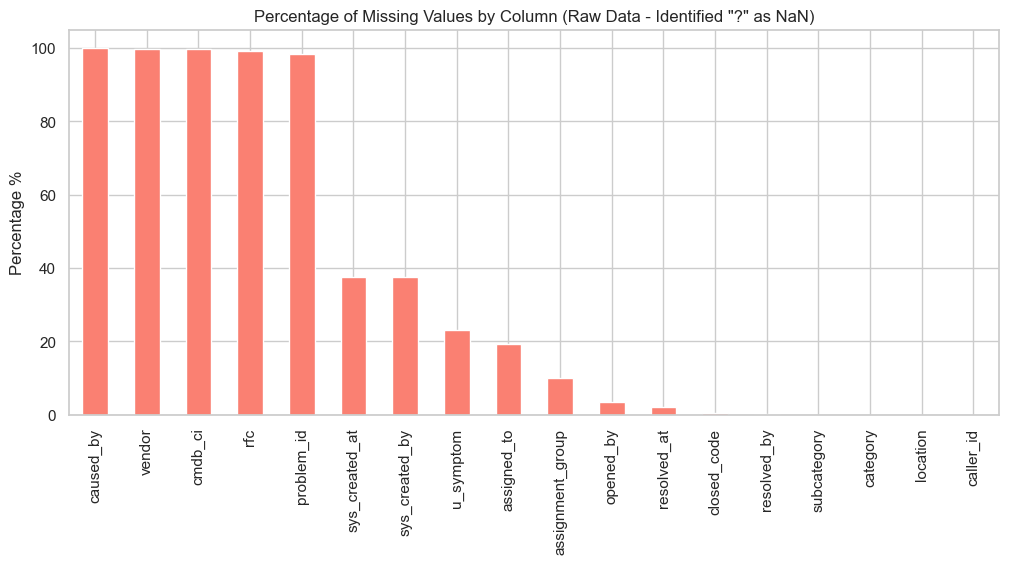

In [28]:
# 3. Check for Missing Values in Raw Data
null_counts = (df_raw.isnull().mean() * 100).sort_values(ascending=False)
null_to_plot = null_counts[null_counts > 0]

plt.figure(figsize=(12, 5))
null_to_plot.plot(kind='bar', color='salmon')
plt.title('Percentage of Missing Values by Column (Raw Data - Identified "?" as NaN)')
plt.ylabel('Percentage %')
plt.show()

## 3. Data Cleaning & Deduplication

The dataset is an event log, thus there are multiple rows existing for the same incident as it transitions through states. Hence, I kept only the last record for each incident to capture its final resolved state. 

In [32]:
# 1. Deduplicate: Keep the last known state for each incident ('number')
# Ensuring sys_updated_at is datetime for accurate sorting
df_raw['sys_updated_at'] = pd.to_datetime(df_raw['sys_updated_at'], errors='coerce')
df = df_raw.sort_values(by='sys_updated_at').groupby('number').last().reset_index()
print(f"Deduplicated unique incidents: {df.shape[0]}")

Deduplicated unique incidents: 24918


In [33]:
# 2. Drop columns with > 40% missing values in the unique incident set
missing_pct = df.isnull().mean() * 100
cols_to_drop = missing_pct[missing_pct > 40].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped columns with >40% nulls: {cols_to_drop}")

Dropped columns with >40% nulls: ['sys_created_by', 'sys_created_at', 'cmdb_ci', 'problem_id', 'rfc', 'vendor', 'caused_by']


## 4. Feature Engineering & Preprocessing

Here, I selected key features that represent the incident's business impact and technical complexity:
* **Priority, Impact, Urgency**: Converted to numeric values; missing values filled with defaults.
* **Resolution Time (Engineered)**: Calculated as (Resolved − Opened) in hours. Outliers capped (99th percentile) and missing values filled with median.
* **Reassignment Count**: Used as a measure of ticket complexity.


In [36]:
# Mapping ordinals consistently
priority_map = {"1 - Critical": 1, "2 - High": 2, "3 - Moderate": 3, "4 - Low": 4, "5 - Planning": 5}
impact_map = {"1 - High": 1, "2 - Medium": 2, "3 - Low": 3}
urgency_map = {"1 - High": 1, "2 - Medium": 2, "3 - Low": 3}

df['priority_val'] = df['priority'].map(priority_map).fillna(3) 
df['impact_val'] = df['impact'].map(impact_map).fillna(2)
df['urgency_val'] = df['urgency'].map(urgency_map).fillna(2)

# Calculating Resolution Time (in hours)
df['opened_at'] = pd.to_datetime(df['opened_at'], errors='coerce')
df['resolved_at'] = pd.to_datetime(df['resolved_at'], errors='coerce')
df['resolution_time_hrs'] = (df['resolved_at'] - df['opened_at']).dt.total_seconds() / 3600

# Handle outliers + fill residue nulls with median
p99 = df['resolution_time_hrs'].quantile(0.99)
df['resolution_time_hrs'] = df['resolution_time_hrs'].clip(lower=0, upper=p99)
df['resolution_time_hrs'].fillna(df['resolution_time_hrs'].median(), inplace=True)

print(f"Resolution time capped at: {p99:.2f} hours")

Resolution time capped at: 2843.40 hours


## 5. Explanatory Data Analysis (EDA)

Using Matplotlib & Seaborn libraries, I created some simple charts to visualize distributions.

### a. Incident Volume by Date

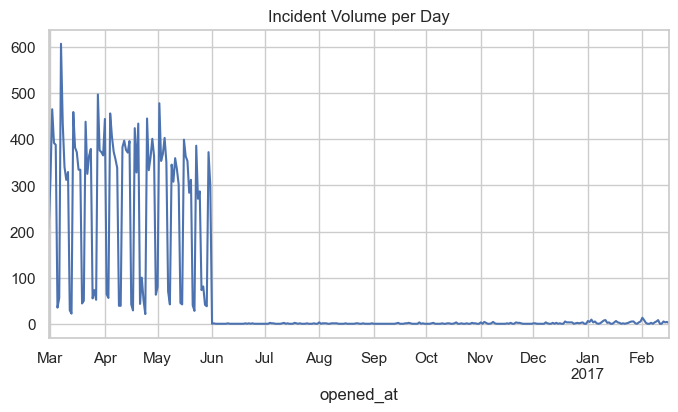

In [40]:
plt.figure(figsize=(8, 4))
df.set_index('opened_at')['number'].resample('D').count().plot(title='Incident Volume per Day')
plt.show()

### b. Priority Distribution

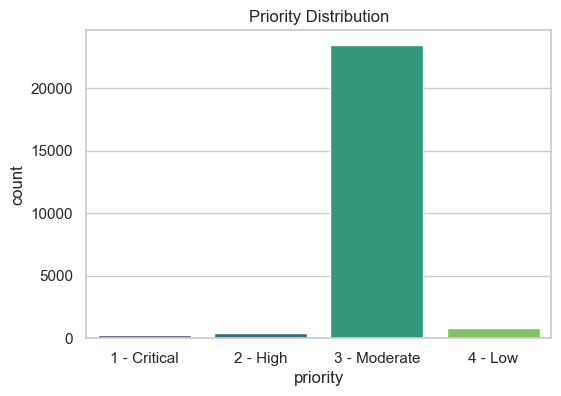

In [41]:
plt.figure(figsize=(6, 4))
sns.countplot(x='priority', data=df, palette='viridis', order=sorted(df['priority'].dropna().unique()))
plt.title('Priority Distribution')
plt.show()

### c. Impact Distribution

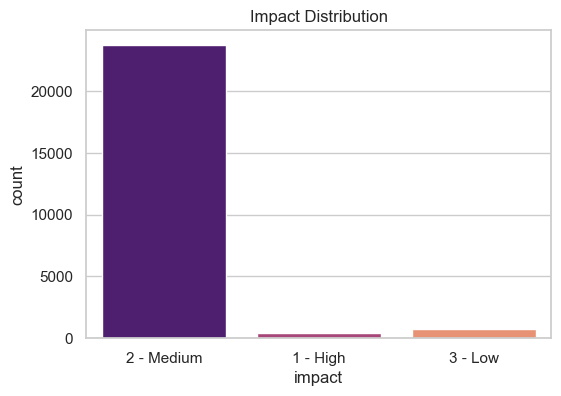

In [42]:
plt.figure(figsize=(6, 4))
sns.countplot(x='impact', data=df, palette='magma')
plt.title('Impact Distribution')
plt.show()

### d. Top 10 Categories

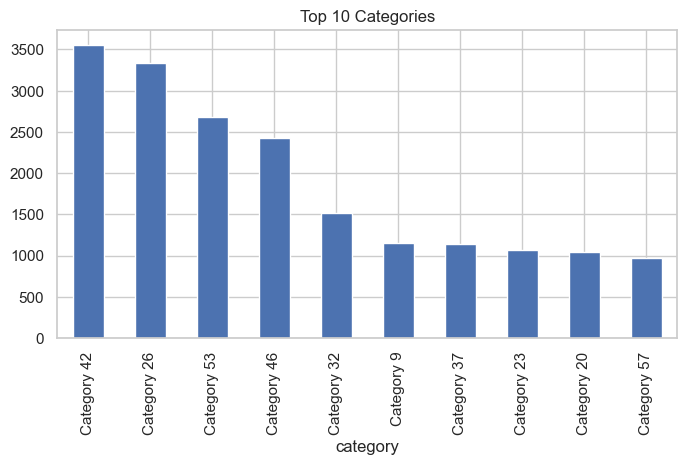

In [43]:
plt.figure(figsize=(8, 4))
df['category'].value_counts().head(10).plot(kind='bar', title='Top 10 Categories')
plt.show()

### e. Top 10 Assignment Groups

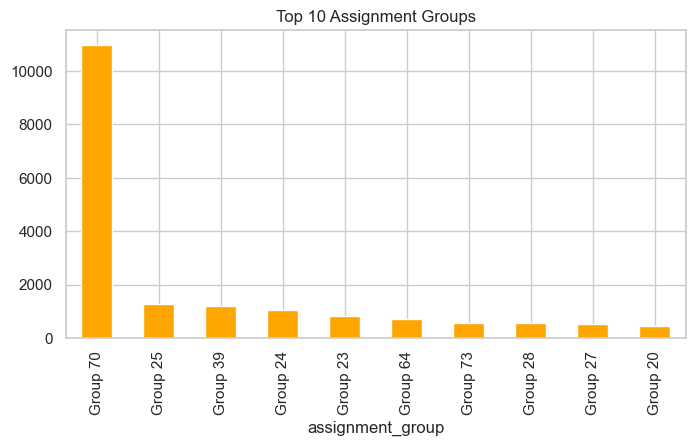

In [44]:
plt.figure(figsize=(8, 4))
df['assignment_group'].value_counts().head(10).plot(kind='bar', color='orange', title='Top 10 Assignment Groups')
plt.show()

### f. Resolution Time Distribution

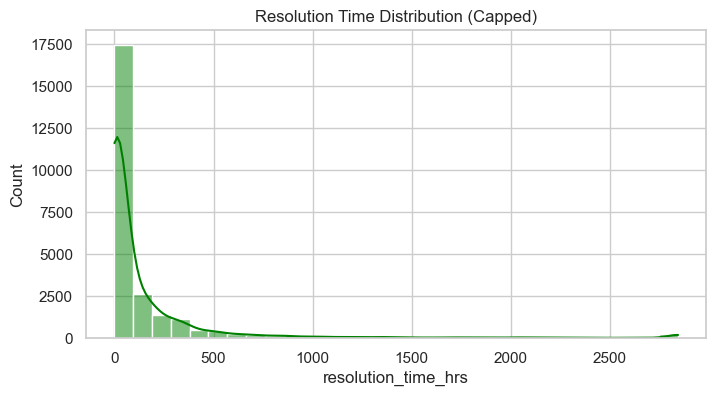

In [45]:
plt.figure(figsize=(8, 4))
sns.histplot(df['resolution_time_hrs'], bins=30, kde=True, color='green')
plt.title('Resolution Time Distribution (Capped)')
plt.show()

### g. Reassignment Count Distribution

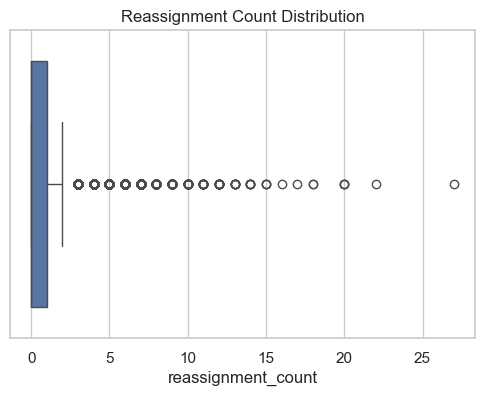

In [46]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='reassignment_count', data=df)
plt.title('Reassignment Count Distribution')
plt.show()

## 6. Modeling Preparations

Standardizing numeric features.

In [49]:
features = ['priority_val', 'impact_val', 'urgency_val', 'resolution_time_hrs', 'reassignment_count']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Standardized feature matrix shape: {X_scaled.shape}")
print(X_scaled[:5])

Standardized feature matrix shape: (24918, 5)
[[ 0.02318265 -0.06117934 -0.0301913  -0.36644425 -0.5977354 ]
 [ 0.02318265 -0.06117934 -0.0301913  -0.31798679  0.03839558]
 [ 0.02318265 -0.06117934 -0.0301913  -0.33955653 -0.5977354 ]
 [ 0.02318265 -0.06117934 -0.0301913  -0.25604294 -0.5977354 ]
 [-3.29673233 -4.6807757  -0.0301913  -0.36984775  0.03839558]]


## 7. Dimensionality Reduction (PCA)

1. Severity (PC1): Priority / Impact / Urgency

2. Complexity (PC2): Resolution Time / Reassignments

PCA Loadings:
                          PC1       PC2
priority_val         0.593160  0.014109
impact_val           0.567357  0.019016
urgency_val          0.570113  0.017159
resolution_time_hrs -0.006389  0.708365
reassignment_count  -0.034619  0.705241


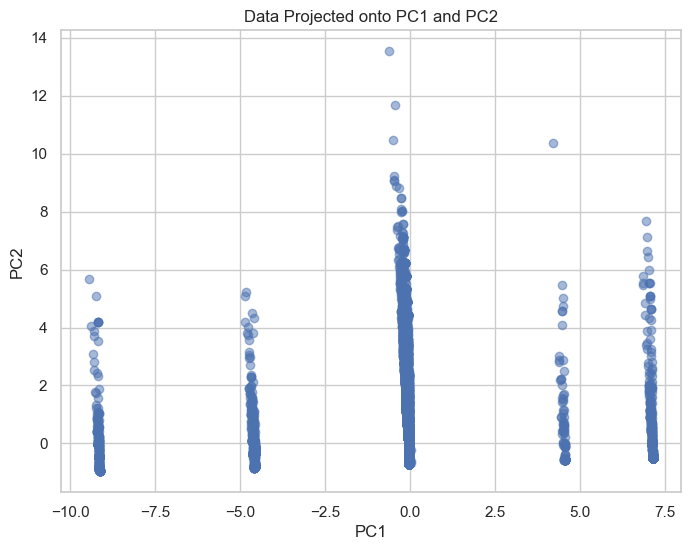

In [52]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features)
print("PCA Loadings:")
print(loadings)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title('Data Projected onto PC1 and PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## 8. Cluster Optimization (Elbow & Silhouette)

Determining the optimal number of clusters (k).

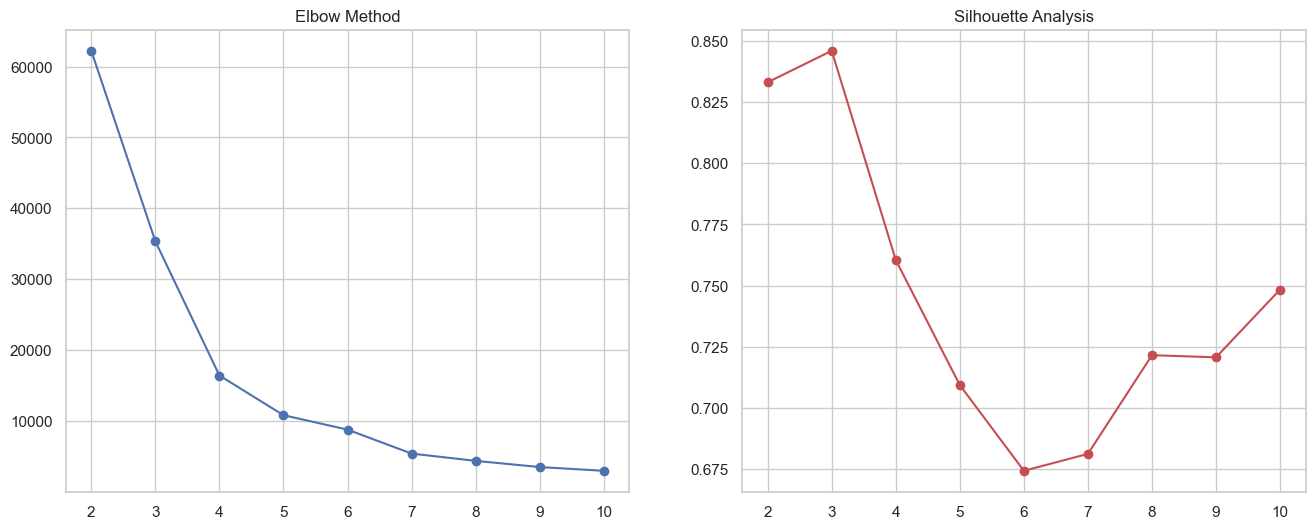

In [53]:
inertia = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.plot(K, inertia, 'bo-')
ax1.set_title('Elbow Method')
ax2.plot(K, silhouette_scores, 'ro-')
ax2.set_title('Silhouette Analysis')
plt.show()

#### I tested k=2 through k=10 using two methods to find the best number of clusters. From the Elbow curve and Silhouette score, I go ahead with **k=3** as the optimal choice.

## 9. Final KMeans Execution & Results

Optimized at k=3.

Cluster Center Statistics (Profiles):
         priority_val  impact_val  urgency_val  resolution_time_hrs  \
cluster                                                               
0             3.00000    2.000170     1.999830           151.264322   
1             4.00000    2.965116     2.901809           199.595016   
2             1.60177    1.379056     1.222714           188.258733   

         reassignment_count  
cluster                      
0                  0.932285  
1                  0.812661  
2                  1.339233  


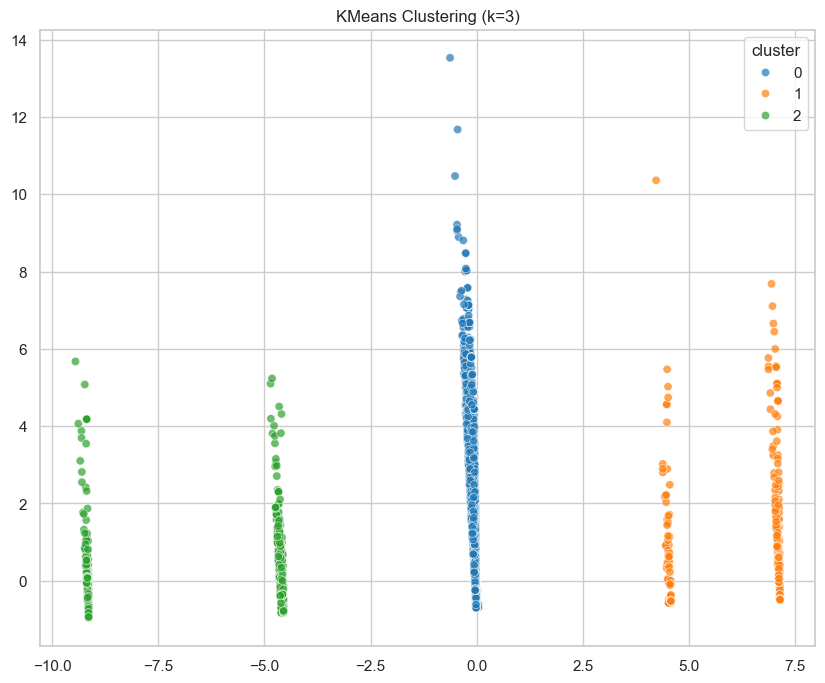

In [54]:
OPTIMAL_K = 3
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42)
df['cluster'] = kmeans_final.fit_predict(X_pca)

profile = df.groupby('cluster')[features].mean()
print("Cluster Center Statistics (Profiles):")
print(profile)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster'], palette='tab10', alpha=0.7)
plt.title(f'KMeans Clustering (k={OPTIMAL_K})')
plt.show()

## 10. Insights & Knowledge Graph

Finally, I plot four knowledge graphs to explore how clusters relate to categories, teams, and priority levels.
Edge values shows incident volume - higher values mean stronger associations.

### Graph 1: Which incident categories belong to each cluster?

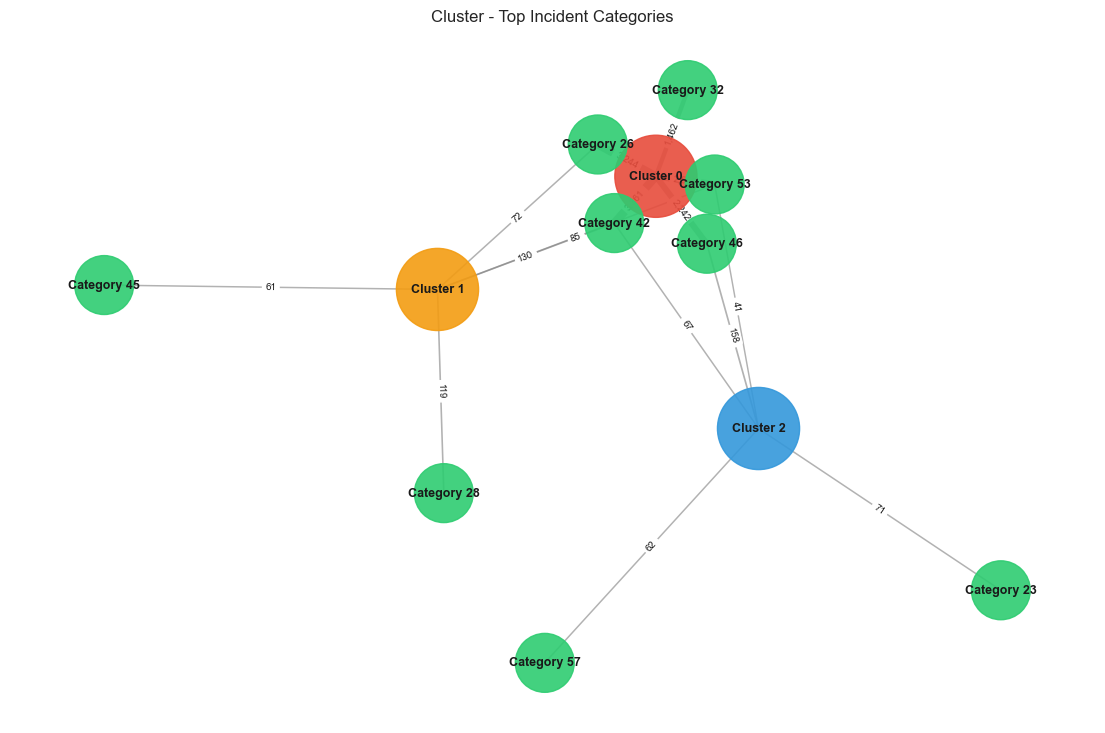

In [64]:
cat_clust = df.groupby(['cluster', 'category']).size().reset_index(name='count')
top_cats = cat_clust.sort_values(['cluster', 'count'], ascending=[True, False]).groupby('cluster').head(5)

G1 = nx.Graph()
for _, row in top_cats.iterrows():
    G1.add_edge(f"Cluster {int(row['cluster'])}", row['category'], weight=int(row['count']))

pos1 = nx.spring_layout(G1, seed=42, k=2.5)
colors = ['#e74c3c', '#f39c12', '#3498db']
cluster_nodes = ['Cluster 0', 'Cluster 1', 'Cluster 2']
node_colors1 = [colors[int(n.split()[-1])] if n in cluster_nodes else '#2ecc71' for n in G1.nodes()]
node_sizes1 = [3500 if n in cluster_nodes else 1800 for n in G1.nodes()]
edge_weights1 = [d['weight'] for _, _, d in G1.edges(data=True)]
edge_widths1 = [1 + 5 * (w / max(edge_weights1)) for w in edge_weights1]

plt.figure(figsize=(14, 9))
nx.draw_networkx_nodes(G1, pos1, node_color=node_colors1, node_size=node_sizes1, alpha=0.9)
nx.draw_networkx_labels(G1, pos1, font_size=9, font_weight='bold')
nx.draw_networkx_edges(G1, pos1, width=edge_widths1, alpha=0.6, edge_color='grey')
nx.draw_networkx_edge_labels(G1, pos1, edge_labels={(u,v): f"{d['weight']:,}" for u,v,d in G1.edges(data=True)}, font_size=7)
plt.title('Cluster - Top Incident Categories')
plt.axis('off')
plt.show()

### Graph 2: Which teams are handling each cluster the most?

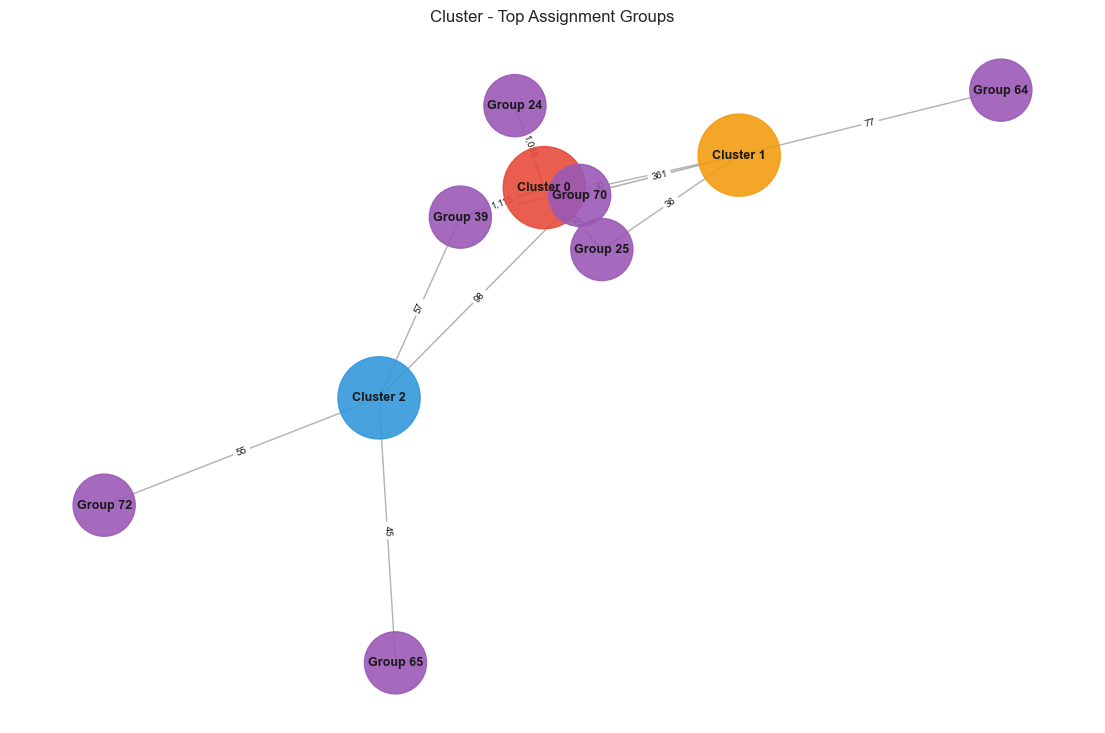

In [65]:
grp_clust = df.groupby(['cluster', 'assignment_group']).size().reset_index(name='count')
top_grps = grp_clust.sort_values(['cluster', 'count'], ascending=[True, False]).groupby('cluster').head(4)

G2 = nx.Graph()
for _, row in top_grps.iterrows():
    G2.add_edge(f"Cluster {int(row['cluster'])}", str(row['assignment_group']), weight=int(row['count']))

pos2 = nx.spring_layout(G2, seed=42, k=2.5)
node_colors2 = [colors[int(n.split()[-1])] if n in cluster_nodes else '#9b59b6' for n in G2.nodes()]
node_sizes2 = [3500 if n in cluster_nodes else 2000 for n in G2.nodes()]
edge_weights2 = [d['weight'] for _, _, d in G2.edges(data=True)]
edge_widths2 = [1 + 5 * (w / max(edge_weights2)) for w in edge_weights2]

plt.figure(figsize=(14, 9))
nx.draw_networkx_nodes(G2, pos2, node_color=node_colors2, node_size=node_sizes2, alpha=0.9)
nx.draw_networkx_labels(G2, pos2, font_size=9, font_weight='bold')
nx.draw_networkx_edges(G2, pos2, width=edge_widths2, alpha=0.6, edge_color='grey')
nx.draw_networkx_edge_labels(G2, pos2, edge_labels={(u,v): f"{d['weight']:,}" for u,v,d in G2.edges(data=True)}, font_size=7)
plt.title('Cluster - Top Assignment Groups')
plt.axis('off')
plt.show()

### Graph 3: How do priority levels distribute across each cluster?

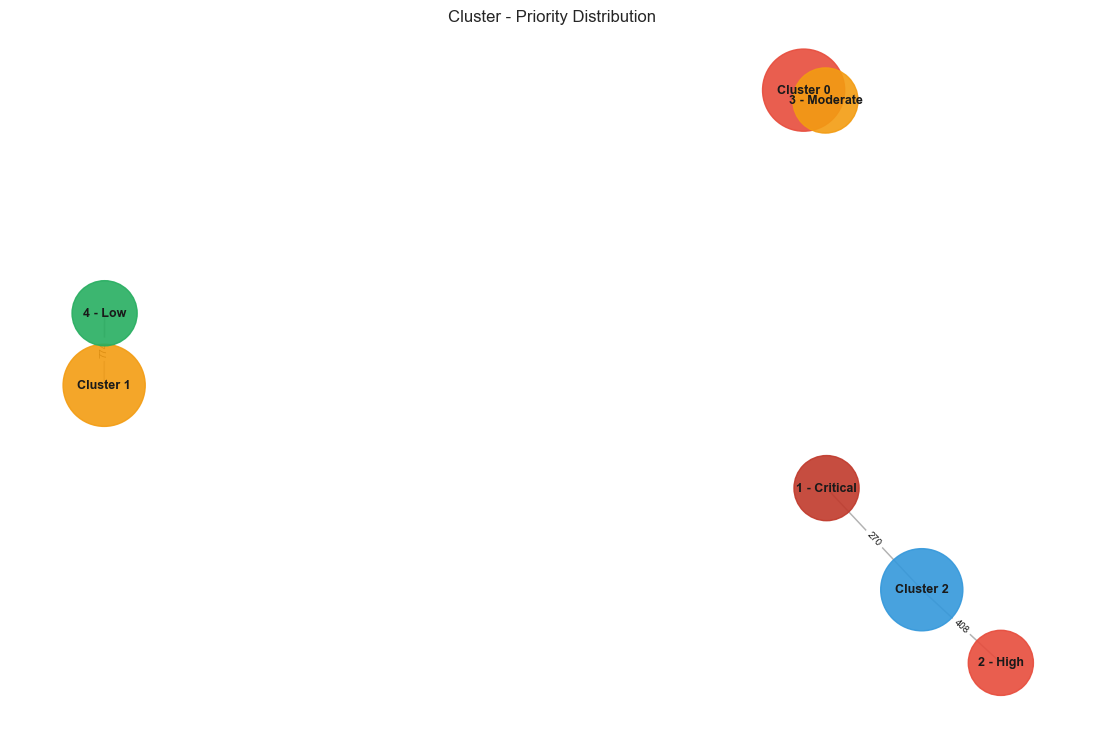

In [68]:
pri_clust = df.groupby(['cluster', 'priority']).size().reset_index(name='count').dropna(subset=['priority'])

G3 = nx.Graph()
for _, row in pri_clust.iterrows():
    G3.add_edge(f"Cluster {int(row['cluster'])}", row['priority'], weight=int(row['count']))

pos3 = nx.spring_layout(G3, seed=42, k=2.5)
priority_colors = {'1 - Critical': '#c0392b', '2 - High': '#e74c3c',
                   '3 - Moderate': '#f39c12', '4 - Low': '#27ae60', '5 - Planning': '#2980b9'}
node_colors3 = [colors[int(n.split()[-1])] if n in cluster_nodes else priority_colors.get(n, '#bdc3c7') for n in G3.nodes()]
node_sizes3 = [3500 if n in cluster_nodes else 2200 for n in G3.nodes()]
edge_weights3 = [d['weight'] for _, _, d in G3.edges(data=True)]
edge_widths3 = [1 + 5 * (w / max(edge_weights3)) for w in edge_weights3]

plt.figure(figsize=(14, 9))
nx.draw_networkx_nodes(G3, pos3, node_color=node_colors3, node_size=node_sizes3, alpha=0.9)
nx.draw_networkx_labels(G3, pos3, font_size=9, font_weight='bold')
nx.draw_networkx_edges(G3, pos3, width=edge_widths3, alpha=0.6, edge_color='grey')
nx.draw_networkx_edge_labels(G3, pos3, edge_labels={(u,v): f"{d['weight']:,}" for u,v,d in G3.edges(data=True)}, font_size=7)
plt.title('Cluster - Priority Distribution')
plt.axis('off')
plt.show()

### Graph 4: Which teams are most associated with which incident categories?

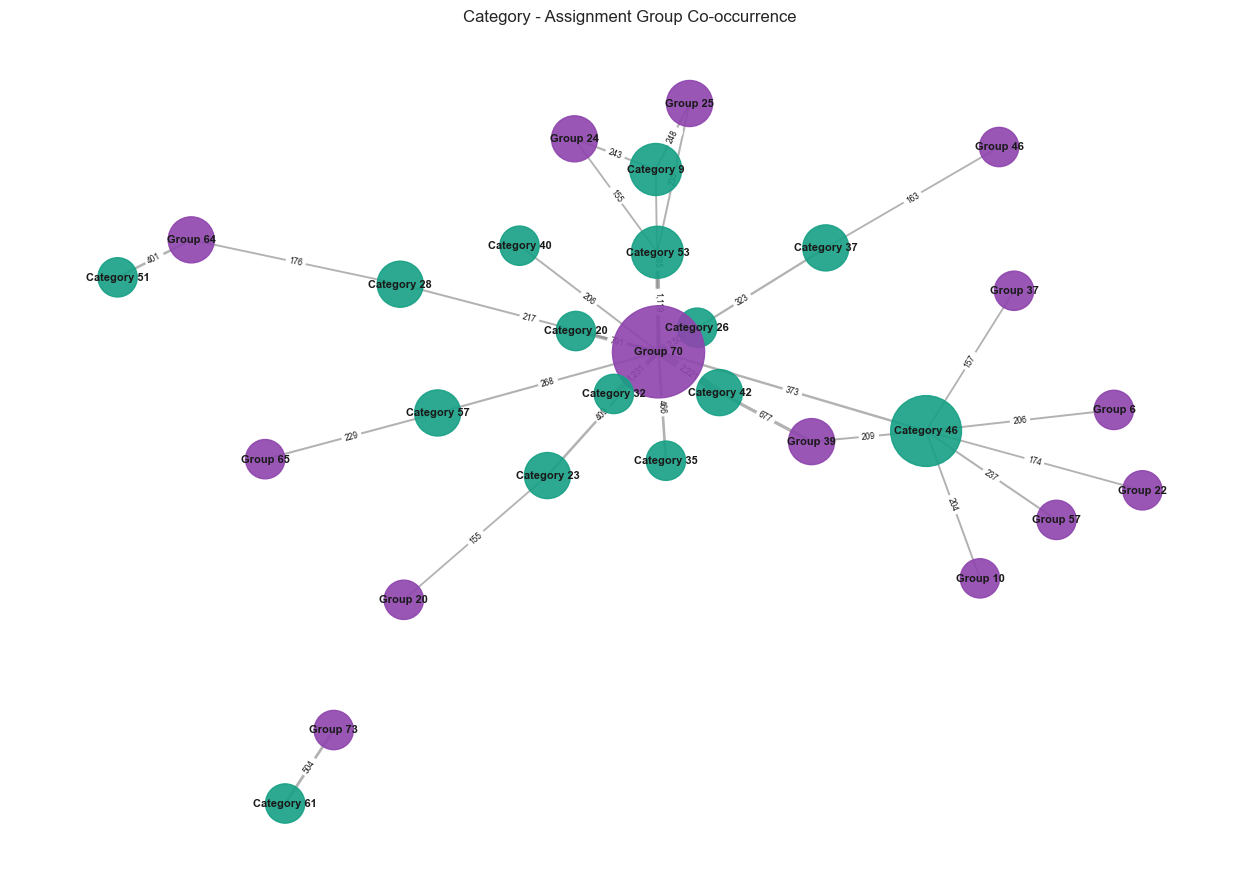

In [69]:
co_occ = df.groupby(['category', 'assignment_group']).size().reset_index(name='count')
co_top = co_occ.sort_values('count', ascending=False).head(30)
cat_set = set(co_top['category'].tolist())

G4 = nx.Graph()
for _, row in co_top.iterrows():
    if pd.notna(row['assignment_group']):
        G4.add_edge(row['category'], row['assignment_group'], weight=int(row['count']))

pos4 = nx.spring_layout(G4, seed=42, k=2.5)
degree4 = dict(G4.degree())
node_colors4 = ['#16a085' if n in cat_set else '#8e44ad' for n in G4.nodes()]
node_sizes4 = [500 + 300 * degree4[n] for n in G4.nodes()]
edge_weights4 = [d['weight'] for _, _, d in G4.edges(data=True)]
edge_widths4 = [1 + 5 * (w / max(edge_weights4)) for w in edge_weights4]

plt.figure(figsize=(16, 11))
nx.draw_networkx_nodes(G4, pos4, node_color=node_colors4, node_size=node_sizes4, alpha=0.9)
nx.draw_networkx_labels(G4, pos4, font_size=8, font_weight='bold')
nx.draw_networkx_edges(G4, pos4, width=edge_widths4, alpha=0.6, edge_color='grey')
nx.draw_networkx_edge_labels(G4, pos4, edge_labels={(u,v): f"{d['weight']:,}" for u,v,d in G4.edges(data=True)}, font_size=6)
plt.title('Category - Assignment Group Co-occurrence')
plt.axis('off')
plt.show()